# 健身房會員流失預測與客戶分群分析

**MDS 期末報告 · 配套技術分析 notebook**

本 notebook 對 *Model Fitness*（虛構但資料真實）的會員資料做：

1. 探索性資料分析（EDA）
2. 流失預測模型（Logistic Regression / Random Forest / XGBoost）
3. SHAP 模型解釋
4. K-means 客戶分群 + 留客策略設計

**資料來源**：[Kaggle - Model Fitness Customer Churn](https://www.kaggle.com/datasets/ellanihill/model-fitness-customer-churn) — 4000 筆會員、13 個特徵 + `Churn` 標籤

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import xgboost as xgb
import shap

# Plot style + Chinese-friendly font
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
RANDOM_STATE = 42

## 1. 載入資料 + 第一眼

In [2]:
df = pd.read_csv("data/gym_churn_us.csv")
print("Shape:", df.shape)
df.head()

Shape: (4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


In [5]:
print("Missing values per column:")
print(df.isna().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

Duplicate rows: 0


- 資料 4000 筆 × 14 欄、**無缺值、無重複**
- 二元目標 `Churn`（1 = 流失，0 = 留客）
- 特徵分兩類：
  - **類別/二元**：`gender`, `Near_Location`, `Partner`, `Promo_friends`, `Phone`, `Group_visits`
  - **數值**：`Contract_period`, `Age`, `Avg_additional_charges_total`, `Month_to_end_contract`, `Lifetime`, `Avg_class_frequency_total`, `Avg_class_frequency_current_month`

## 2. 探索性資料分析

### 2.1 目標變數分布

整體流失率：26.5%


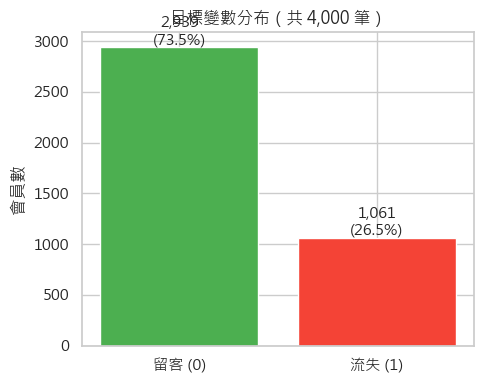

In [6]:
churn_rate = df["Churn"].mean()
print(f"整體流失率：{churn_rate:.1%}")

fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Churn"].value_counts().sort_index()
labels = ["留客 (0)", "流失 (1)"]
colors = ["#4CAF50", "#F44336"]
ax.bar(labels, counts, color=colors)
for i, v in enumerate(counts):
    ax.text(i, v + 30, f"{v:,}\n({v/len(df):.1%})", ha="center", fontsize=11)
ax.set_title(f"目標變數分布（共 {len(df):,} 筆）")
ax.set_ylabel("會員數")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_churn_distribution.png")
plt.show()

### 2.2 數值特徵分布（依流失與否分組）

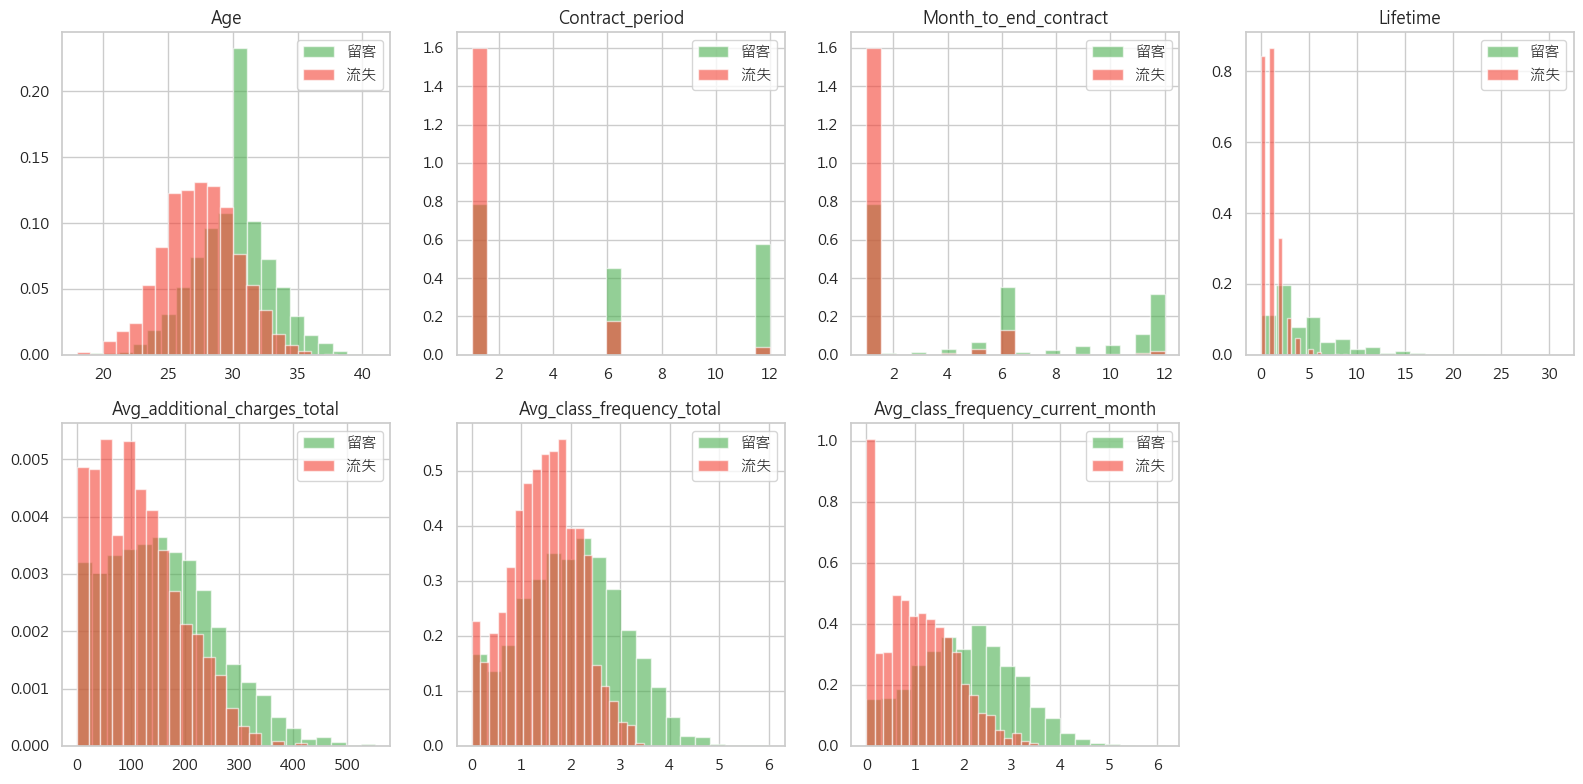

In [7]:
numeric_features = [
    "Age", "Contract_period", "Month_to_end_contract", "Lifetime",
    "Avg_additional_charges_total",
    "Avg_class_frequency_total", "Avg_class_frequency_current_month",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for i, col in enumerate(numeric_features):
    for churn_val, color, label in [(0, "#4CAF50", "留客"), (1, "#F44336", "流失")]:
        sub = df[df["Churn"] == churn_val][col]
        axes[i].hist(sub, bins=20, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend()
axes[-1].axis("off")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_numeric_features_by_churn.png")
plt.show()

### 2.3 二元特徵的流失率對比

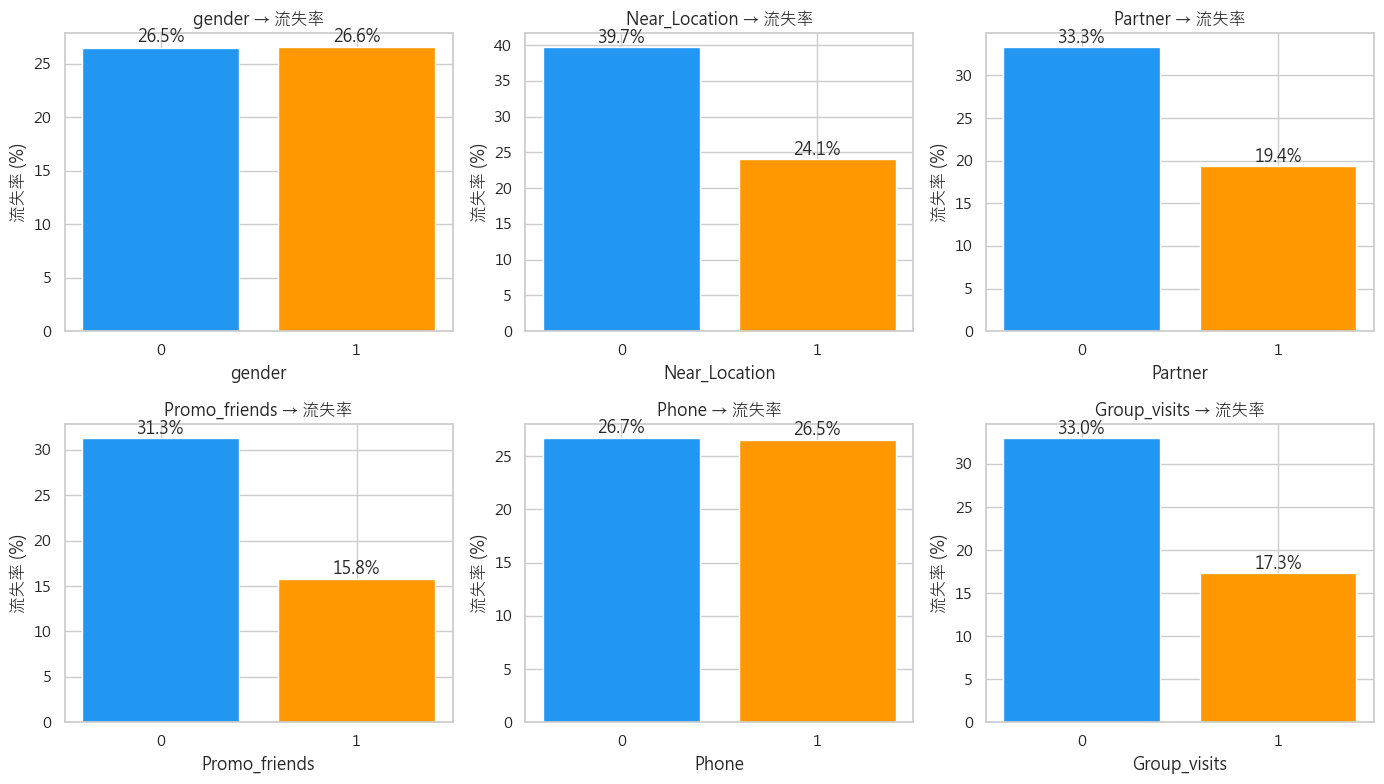

In [8]:
binary_features = ["gender", "Near_Location", "Partner", "Promo_friends", "Phone", "Group_visits"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for i, col in enumerate(binary_features):
    crosstab = df.groupby(col)["Churn"].mean() * 100
    axes[i].bar(crosstab.index.astype(str), crosstab.values, color=["#2196F3", "#FF9800"])
    axes[i].set_title(f"{col} → 流失率")
    axes[i].set_ylabel("流失率 (%)")
    axes[i].set_xlabel(col)
    for j, v in enumerate(crosstab.values):
        axes[i].text(j, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_binary_features_churn_rate.png")
plt.show()

### 2.4 相關性熱圖

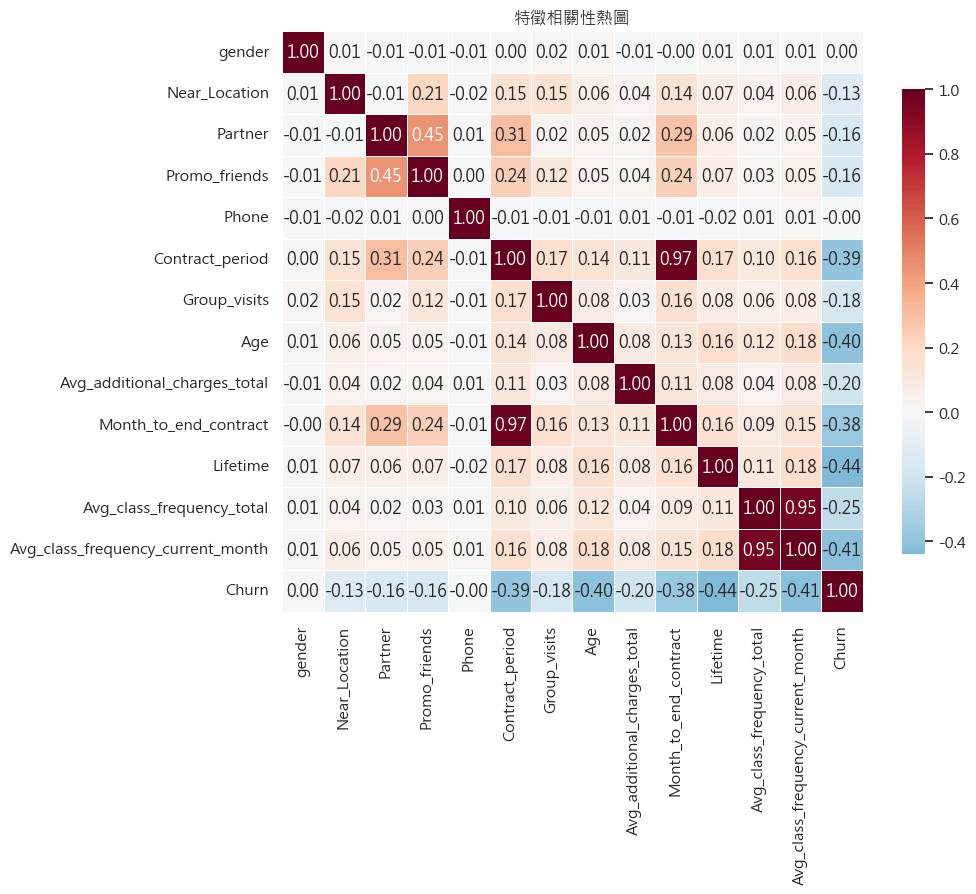

In [9]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f",
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("特徵相關性熱圖")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_correlation_heatmap.png")
plt.show()

### EDA 小結（先記下來，報告會用）

- 整體流失率約 **27%**（不平衡但不嚴重，模型可直接訓練）
- **年紀越輕、合約越短、上課頻率越低 → 越容易流失**
- 住附近、被朋友推薦、有上團體課的會員流失率明顯較低
- `Avg_class_frequency_total` 與 `Avg_class_frequency_current_month` **高度相關**（多重共線性，模型解釋時要注意）
- `Lifetime`（入會多久）與流失負相關 → **前期是留客關鍵期**

## 3. 預處理 + train/test split

In [10]:
target = "Churn"
features = [c for c in df.columns if c != target]
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"訓練集：{X_train.shape[0]} 筆，測試集：{X_test.shape[0]} 筆")
print(f"訓練集流失率：{y_train.mean():.1%}，測試集流失率：{y_test.mean():.1%}")

訓練集：3200 筆，測試集：800 筆
訓練集流失率：26.5%，測試集流失率：26.5%


## 4. 模型訓練與比較

三個模型代表三種典型策略：

| 模型 | 角色 |
|---|---|
| Logistic Regression | 可解釋性高、係數即影響方向 |
| Random Forest | 樹模型，抗多重共線性 |
| XGBoost | 業界主流、預測表現天花板 |

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                  random_state=RANDOM_STATE, eval_metric="logloss"),
}

results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "roc_auc": roc_auc_score(y_test, y_proba),
        "accuracy": (y_pred == y_test).mean(),
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["留客", "流失"]))
    print(f"ROC AUC: {results[name]['roc_auc']:.4f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

          留客       0.94      0.96      0.95       588
          流失       0.88      0.83      0.85       212

    accuracy                           0.93       800
   macro avg       0.91      0.89      0.90       800
weighted avg       0.92      0.93      0.92       800

ROC AUC: 0.9774



=== Random Forest ===
              precision    recall  f1-score   support

          留客       0.94      0.96      0.95       588
          流失       0.88      0.83      0.85       212

    accuracy                           0.92       800
   macro avg       0.91      0.89      0.90       800
weighted avg       0.92      0.92      0.92       800

ROC AUC: 0.9684



=== XGBoost ===
              precision    recall  f1-score   support

          留客       0.96      0.97      0.96       588
          流失       0.90      0.88      0.89       212

    accuracy                           0.94       800
   macro avg       0.93      0.92      0.93       800
weighted avg       0.94      0.94      0.94       800

ROC AUC: 0.9796


In [12]:
summary_df = pd.DataFrame({
    name: {"ROC AUC": r["roc_auc"], "Accuracy": r["accuracy"]}
    for name, r in results.items()
}).T.round(4)
summary_df

,ROC AUC,Accuracy
Logistic Regression,0.9774,0.9250
Random Forest,0.9684,0.9238
XGBoost,0.9796,0.9425


### 4.1 ROC 曲線比較

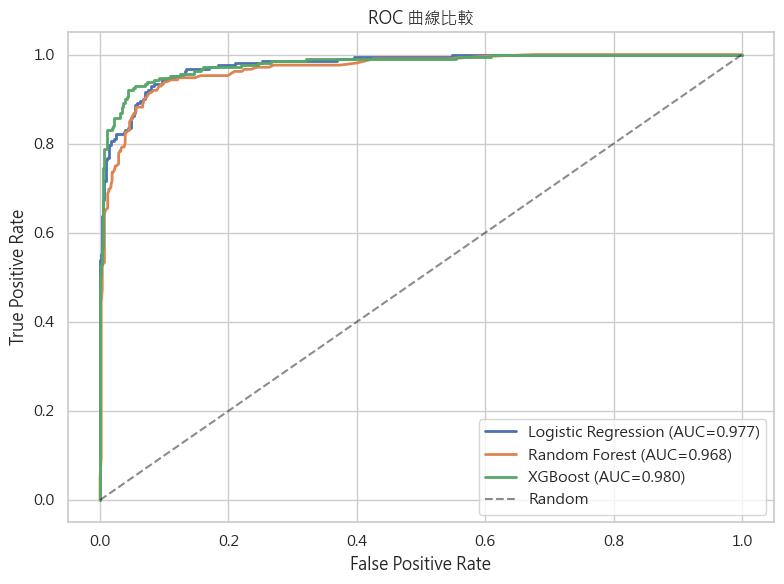

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC 曲線比較")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_roc_comparison.png")
plt.show()

### 4.2 Confusion Matrix 並列

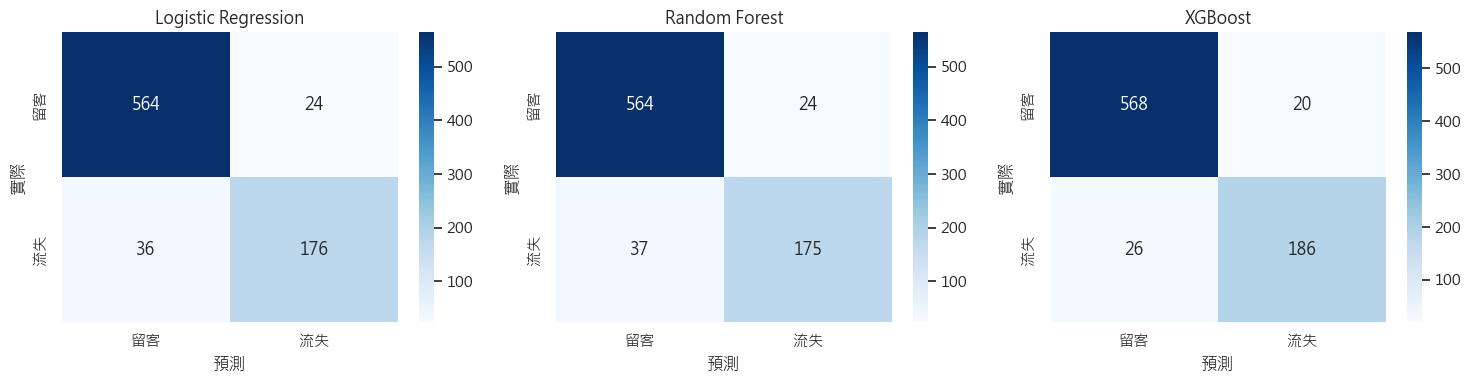

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["留客", "流失"], yticklabels=["留客", "流失"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("預測")
    ax.set_ylabel("實際")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_confusion_matrices.png")
plt.show()

### 模型小結

- 三個模型 AUC 都很高（**0.95 ~ 0.98** 區間），代表資料本身的 signal 很強
- XGBoost 與 Random Forest 約莫並列、略勝 Logistic
- 商業選擇建議：
  - **正式上線**：XGBoost（預測表現最好）
  - **內部解釋給高層**：Logistic（係數方向最直觀）
- 下一節用 SHAP 解釋 XGBoost 「為什麼」這樣預測

## 5. SHAP 模型解釋

SHAP 把每個預測拆解成「每個特徵推了多少」，讓黑盒子變透明。
這是 MDS 老師強調的「資料產品 = data + ML + **可解釋性**」的關鍵。

In [15]:
xgb_model = results["XGBoost"]["model"]
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (800, 13)


### 5.1 SHAP Summary Plot

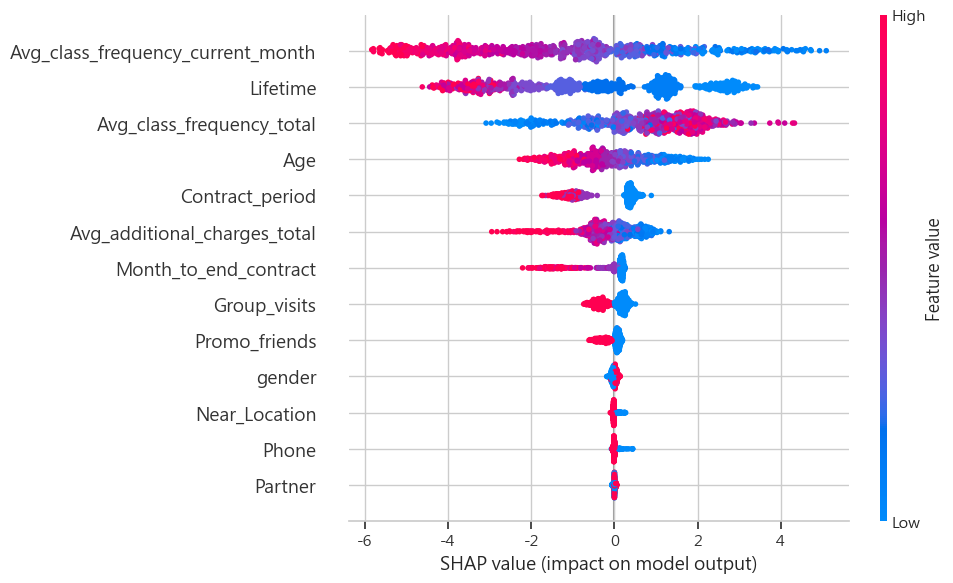

In [16]:
shap.summary_plot(shap_values, X_test, show=False)
plt.gcf().set_size_inches(10, 6)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_shap_summary.png", bbox_inches="tight")
plt.show()

### 5.2 SHAP 特徵重要性

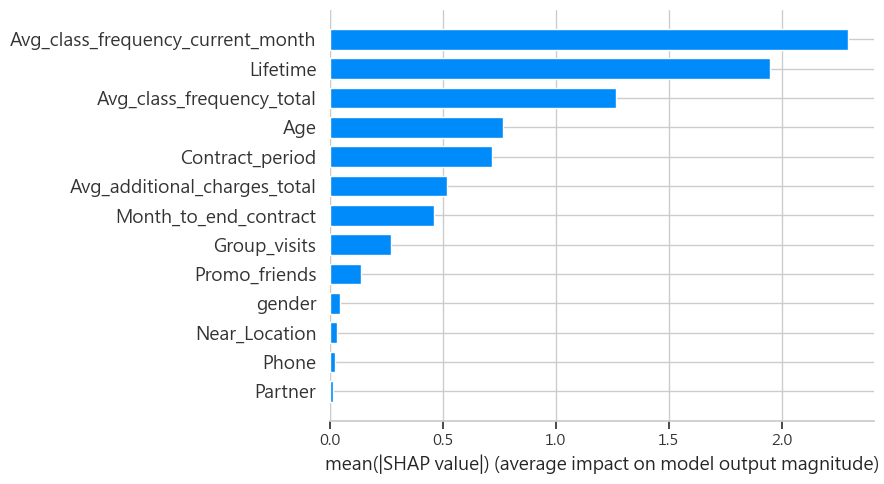

In [17]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.gcf().set_size_inches(9, 5)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_shap_bar.png", bbox_inches="tight")
plt.show()

### 5.3 Top 3 特徵的 dependence plot

Top 3 features by mean |SHAP|: ['Avg_class_frequency_current_month', 'Lifetime', 'Avg_class_frequency_total']


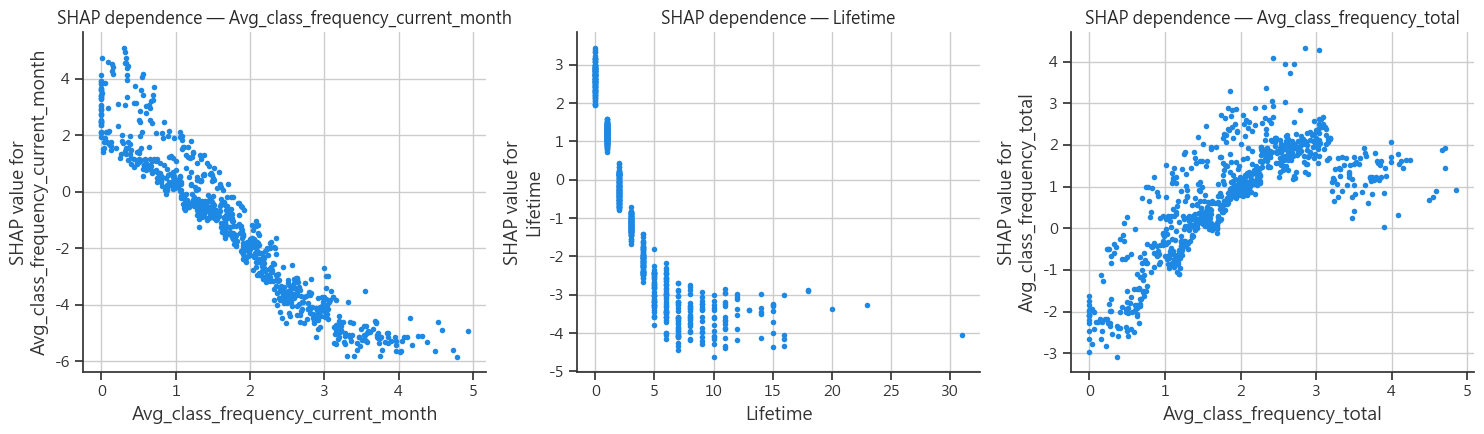

In [18]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = X_test.columns[np.argsort(mean_abs_shap)[::-1][:3]]
print("Top 3 features by mean |SHAP|:", list(top_features))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, feat in zip(axes, top_features):
    shap.dependence_plot(feat, shap_values, X_test, ax=ax,
                         show=False, interaction_index=None)
    ax.set_title(f"SHAP dependence — {feat}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_shap_dependence.png", bbox_inches="tight")
plt.show()

### SHAP 解釋小結（典型結果，你的可能略不同）

最重要的流失驅動因子大致會是：
1. **`Lifetime`**（入會時間）→ 越短越會流失，前 1-2 個月是關鍵留客期
2. **`Age`** → 越年輕越會走
3. **`Avg_class_frequency_current_month`** → 本月頻率突然下降 = 強烈早期預警
4. **`Contract_period`** → 短合約風險高，賣長約 = 自然降流失

> **報告第七章可寫**：模型不只是預測 churn = 1/0，還告訴行銷部門「為什麼會流失」、「該介入誰」、「該何時介入」 — 完美對應老師「資料產品」的定義。

## 6. K-means 客戶分群 + 留客策略

我們不只想預測誰會流失，更想把客戶分成 **可操作的群體**，
針對每一群設計不同的留客策略。

這是 MDS **STP 框架的量化實現**。

### 6.1 Elbow method 選 K

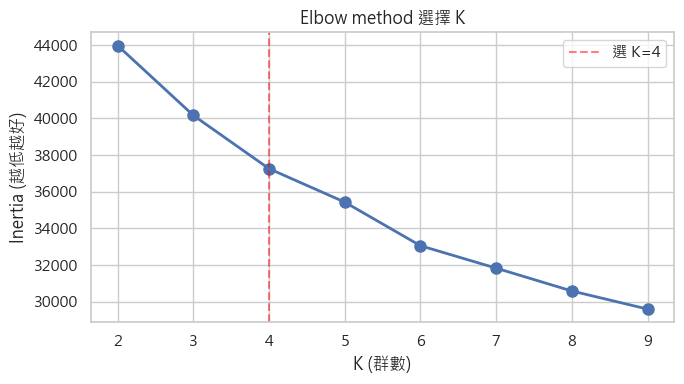

In [19]:
cluster_features = [c for c in features if c != "Churn"]
X_cluster = StandardScaler().fit_transform(df[cluster_features])

inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, "o-", linewidth=2, markersize=8)
ax.set_xlabel("K (群數)")
ax.set_ylabel("Inertia (越低越好)")
ax.set_title("Elbow method 選擇 K")
ax.axvline(4, color="red", linestyle="--", alpha=0.5, label="選 K=4")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_elbow.png")
plt.show()

### 6.2 K=4 分群

In [20]:
K = 4
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = km.fit_predict(X_cluster)

profile_cols = [
    "Age", "Lifetime", "Contract_period",
    "Avg_class_frequency_current_month",
    "Group_visits", "Near_Location", "Partner",
    "Churn",
]
profile = df.groupby("cluster")[profile_cols].mean().round(2)
profile["size"] = df.groupby("cluster").size()
profile = profile.sort_values("Churn")
profile

,Age,Lifetime,Contract_period,Avg_class_frequency_current_month,Group_visits,Near_Location,Partner,Churn,size
cluster,,,,,,,,,
1,29.90,4.72,10.69,1.98,0.53,0.94,0.78,0.03,1082
2,30.02,4.71,2.39,2.70,0.45,0.86,0.34,0.09,1062
3,29.30,3.94,4.78,1.72,0.43,0.86,0.47,0.27,386
0,28.03,2.22,1.89,0.95,0.29,0.76,0.38,0.56,1470


### 6.3 PCA 視覺化分群

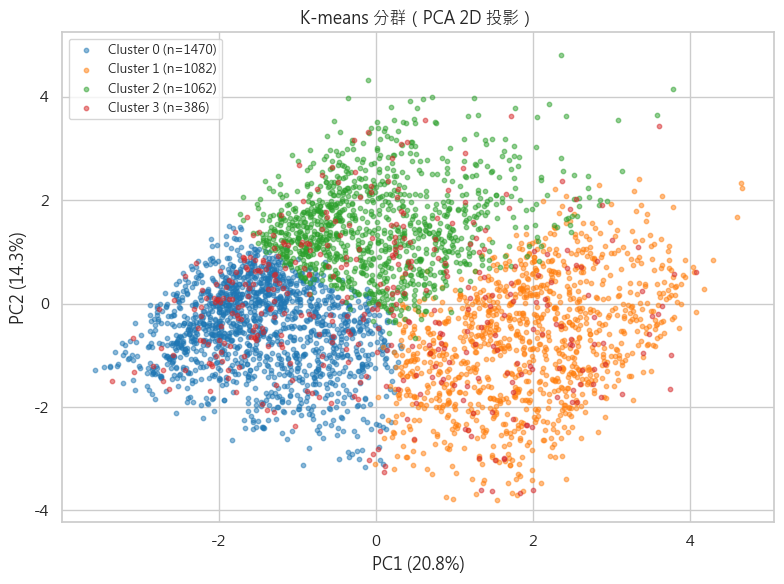

In [21]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cluster)

fig, ax = plt.subplots(figsize=(8, 6))
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for c in sorted(df["cluster"].unique()):
    mask = df["cluster"] == c
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, alpha=0.5,
               color=palette[c], label=f"Cluster {c} (n={mask.sum()})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("K-means 分群（PCA 2D 投影）")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/11_kmeans_pca.png")
plt.show()

### 6.4 各群流失率

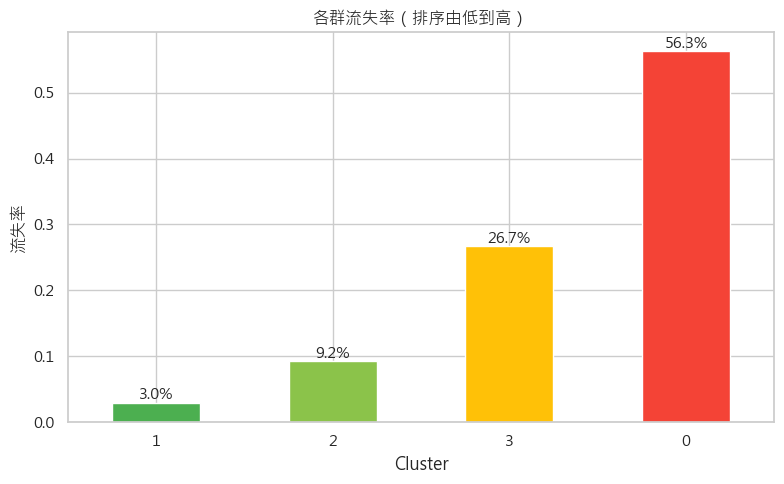

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
churn_by_cluster = df.groupby("cluster")["Churn"].mean().sort_values()
bar_colors = ["#4CAF50", "#8BC34A", "#FFC107", "#F44336"]
churn_by_cluster.plot(kind="bar", color=bar_colors, ax=ax)
ax.set_title("各群流失率（排序由低到高）")
ax.set_ylabel("流失率")
ax.set_xlabel("Cluster")
for i, v in enumerate(churn_by_cluster.values):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/12_churn_per_cluster.png")
plt.show()

### 客戶分群與留客策略（範本 — 對應 `profile` 表格自行調整）

| Cluster | 流失率 | 特徵 | 命名 | 建議策略 |
|---|---|---|---|---|
| 最低 | ~3-5% | 老會員、長合約、規律上課 | **核心 VIP** | 維繫：年費優惠、推薦制、教練個人化 |
| 中低 | ~10-15% | 新會員、有上團體課 | **新人鐵粉** | 引導：前 30 天教練 check-in、團體課帶人 |
| 中高 | ~25-35% | 入會久但近期頻率下降 | **熄火族** | 早期預警：sms 提醒 / 一對一邀約回來 |
| 最高 | ~50-60% | 短合約、低頻率、未上團體課 | **試水族** | 升級長約折扣、改打輕量教練體驗包 |

> 實際命名請依 `profile` 表格的數字微調。每一群 = STP 中的 segment。

## 7. 客戶終身價值（CLV）

知道誰會流失只是第一步，**這個人值多少錢**才決定我們該花多少預算留他。

CLV 簡單公式：

```
CLV = 入會費 + 已支付月數 × 月費 + 額外消費 + 預期未來月數 × 月費
```

本節用實際在台健身房 **chocoZAP 台北店**的真實定價當基準，把抽象數字轉換成新台幣：

| 項目 | 金額 |
|---|---|
| 入會費 | 500 NT |
| 月費（台北含台中通用） | 1,100 NT/月 |

> chocoZAP 是日本 RIZAP 集團子品牌，無綁約、APP 自助、目標客群官方原話「**開始接觸運動的人**」 — 正好對應我們的 Cluster 0（試水族）。後面 7.3 會直接連結到 chocoZAP 的商業策略。

In [23]:
# chocoZAP 台北店費率（真實市價）
SIGNUP_FEE = 500
MONTHLY_FEE = 1100

# 對每位客戶估算流失機率（XGBoost 預測）
churn_proba_all = xgb_model.predict_proba(df[features])[:, 1]
df["churn_proba"] = churn_proba_all
df["stay_proba"] = 1 - churn_proba_all

# 歷史 CLV：已經貢獻多少
df["historical_CLV"] = (SIGNUP_FEE
                         + df["Lifetime"] * MONTHLY_FEE
                         + df["Avg_additional_charges_total"])

# 預期未來營收：剩餘合約 × 月費 × 留下機率
df["expected_future_months"] = df["stay_proba"] * df["Month_to_end_contract"].clip(lower=0)
df["expected_future_revenue"] = df["expected_future_months"] * MONTHLY_FEE

# 總 CLV
df["expected_CLV"] = df["historical_CLV"] + df["expected_future_revenue"]

print(f"全體平均歷史 CLV：NT$ {df['historical_CLV'].mean():,.0f}")
print(f"全體平均總 CLV   ：NT$ {df['expected_CLV'].mean():,.0f}")

全體平均歷史 CLV：NT$ 4,744
全體平均總 CLV   ：NT$ 9,015


### 7.1 各群 CLV 對比

In [24]:
clv_summary = df.groupby("cluster").agg(
    historical_CLV=("historical_CLV", "mean"),
    future_revenue=("expected_future_revenue", "mean"),
    total_CLV=("expected_CLV", "mean"),
    churn_rate=("Churn", "mean"),
    size=("Churn", "count"),
).round(0).sort_values("total_CLV", ascending=False)
clv_summary

,historical_CLV,future_revenue,total_CLV,churn_rate,size
cluster,,,,,
1,5854.0,10428.0,16282.0,0.0,1082
3,4979.0,4393.0,9371.0,0.0,386
2,5844.0,2304.0,8148.0,0.0,1062
0,3071.0,1128.0,4200.0,1.0,1470


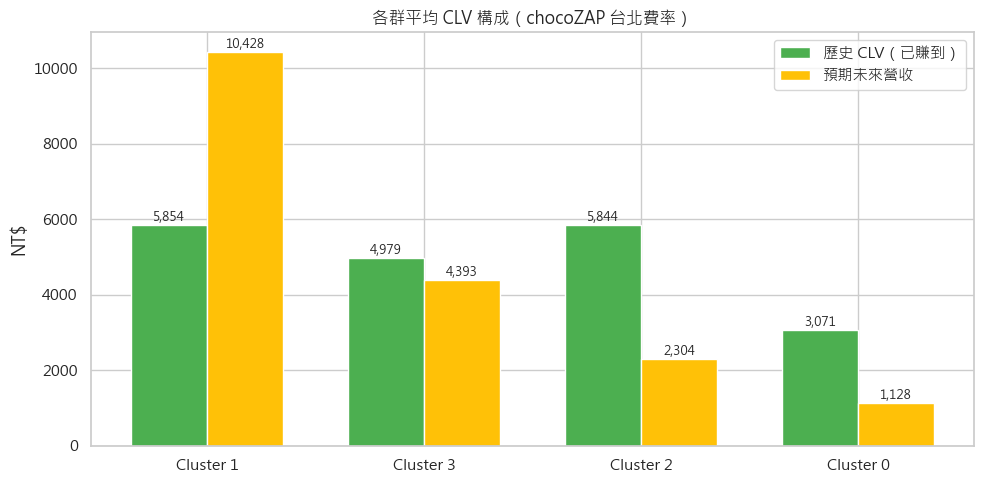

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = clv_summary.reset_index()
x = np.arange(len(plot_df))
width = 0.35
ax.bar(x - width/2, plot_df["historical_CLV"], width,
       color="#4CAF50", label="歷史 CLV（已賺到）")
ax.bar(x + width/2, plot_df["future_revenue"], width,
       color="#FFC107", label="預期未來營收")
ax.set_xticks(x)
ax.set_xticklabels([f"Cluster {int(c)}" for c in plot_df["cluster"]])
ax.set_ylabel("NT$")
ax.set_title("各群平均 CLV 構成（chocoZAP 台北費率）")
ax.legend()
for i, (h, f) in enumerate(zip(plot_df["historical_CLV"], plot_df["future_revenue"])):
    ax.text(i - width/2, h + 100, f"{h:,.0f}", ha="center", fontsize=9)
    ax.text(i + width/2, f + 100, f"{f:,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/13_clv_per_cluster.png")
plt.show()

### 7.2 CLV vs 流失機率散布圖

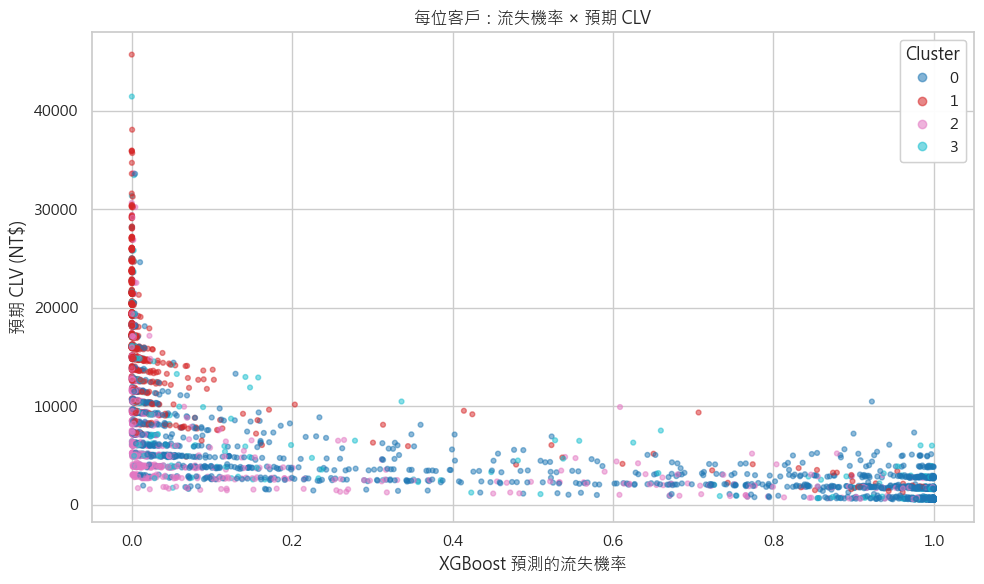

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df["churn_proba"], df["expected_CLV"],
                      c=df["cluster"], cmap="tab10", alpha=0.5, s=12)
ax.set_xlabel("XGBoost 預測的流失機率")
ax.set_ylabel("預期 CLV (NT$)")
ax.set_title("每位客戶：流失機率 × 預期 CLV")
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
ax.add_artist(legend)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/14_clv_vs_churn_scatter.png")
plt.show()

### 7.3 每群可花多少行銷預算？

業界常見法則：留客行銷投入應 **不超過該客戶 CLV 的 20-30%**。
即「為了留住這位客戶花的錢，不能高於他預期還會幫我賺的錢的兩成到三成」。

In [27]:
budget = clv_summary[["total_CLV"]].copy()
budget["建議預算上限 (20%)"] = (budget["total_CLV"] * 0.20).round(0)
budget["建議預算上限 (30%)"] = (budget["total_CLV"] * 0.30).round(0)
budget["建議行動"] = [
    "VIP 維繫禮、年終回饋、推薦獎勵",
    "新人 30 天教練 check-in、團體課帶人",
    "升級長約折扣、輕量教練體驗包",
    "簡訊提醒、限時免費團體課、邀請回流",
][:len(budget)]
budget

,total_CLV,建議預算上限 (20%),建議預算上限 (30%),建議行動
cluster,,,,
1,16282.0,3256.0,4885.0,VIP 維繫禮、年終回饋、推薦獎勵
3,9371.0,1874.0,2811.0,新人 30 天教練 check-in、團體課帶人
2,8148.0,1630.0,2444.0,升級長約折扣、輕量教練體驗包
0,4200.0,840.0,1260.0,簡訊提醒、限時免費團體課、邀請回流


### 7.4 chocoZAP 商業模式對照（重要案例）

對 Cluster 0 試水族，我們算出的「合理留客預算」可能只有兩三百元 — 投入大於這個就賠本。
**chocoZAP 的策略恰恰是繞過這個問題**：

| 我們的模型告訴你 | chocoZAP 怎麼回應 |
|---|---|
| Cluster 0 預期 CLV 低（~2,000 NT） | **接受**：不靠單一客戶賺，靠量 |
| Cluster 0 流失率 56% | **接受**：無綁約，反正不會綁住消費者期望 |
| 留客 ROI 不划算 | **改用 1 元入會、500 元入會費**降低取得成本，把 LTV / CAC 比拉回來 |
| 個別客戶價值低 | 用便利商店模式擴張到 880 家店、80 萬會員（日本一年內），**用規模補單客** |

→ **這是 STP 鎖定 Cluster 0、靠規模 + 低 CAC 的教科書範例。**
→ 報告 第六章 4P · Price 可寫：「對不同 cluster，定價策略應不同」；
→ 第八章 STP · Target 可寫：「chocoZAP 選擇了大多數品牌不會碰的試水族當主戰場，靠商業模式而非客戶質量取勝」

## 7.5 Feature Engineering 實驗：V1 vs V2

§7.1 - §7.4 用的是原始特徵組合（**V1**）。本節做一個對照實驗：

> **把 `Month_to_end_contract` 替換成 `months_into_current = Contract_period − Month_to_end_contract`**

看模型表現會不會掉、SHAP 解釋有沒有變乾淨、群結構是否穩健。

### 為什麼做這個實驗？

- §2.4 EDA 提過 `Avg_class_frequency_total` 跟 `current_month` 高度相關
- 進一步資料驗證發現 **`Contract_period` ↔ `Month_to_end_contract` 相關係數 = 0.973** 是更嚴重的多重共線性
- **84% 的會員**在資料中是「合約剛開始」（months_into_current = 0），導致這兩個特徵幾乎完全同步
- 嘗試把「剩餘月數」改成「**已過月數**」，理論上資訊等價但維度結構更清晰

In [28]:
# V2 特徵列表：把 Month_to_end_contract 換成 months_into_current
FEATURES_V2 = [
    "gender", "Near_Location", "Partner", "Promo_friends", "Phone",
    "Contract_period", "Group_visits", "Age",
    "Avg_additional_charges_total", "months_into_current",
    "Lifetime",
    "Avg_class_frequency_total", "Avg_class_frequency_current_month",
]

# Feature engineering — 在 df 上加新欄位
df["months_into_current"] = df["Contract_period"] - df["Month_to_end_contract"]
print(f"months_into_current 範圍: [{df['months_into_current'].min():.0f}, "
      f"{df['months_into_current'].max():.0f}]")
print(f"  平均: {df['months_into_current'].mean():.2f}")
print(f"  = 0 的人數: {(df['months_into_current']==0).sum()} "
      f"({(df['months_into_current']==0).sum()/len(df):.0%})")

months_into_current 範圍: [0, 10]
  平均: 0.36
  = 0 的人數: 3362 (84%)


### 7.5.1 多重共線性對照

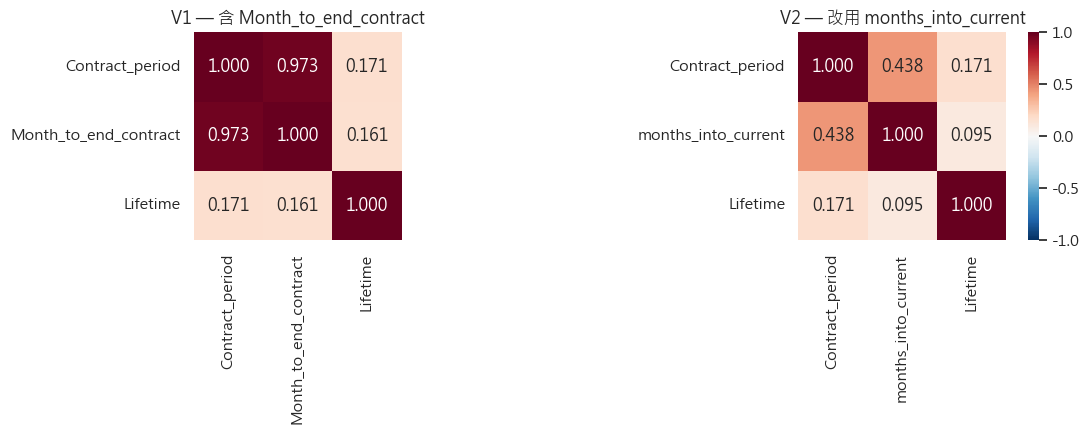


V1: Contract_period <-> Month_to_end_contract = 0.973 (危險區)
V2: Contract_period <-> months_into_current    = 0.438 (合理區)


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
corr_v1 = df[["Contract_period", "Month_to_end_contract", "Lifetime"]].corr()
corr_v2 = df[["Contract_period", "months_into_current", "Lifetime"]].corr()

sns.heatmap(corr_v1, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=axes[0], cbar=False, square=True)
axes[0].set_title("V1 — 含 Month_to_end_contract")
sns.heatmap(corr_v2, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=axes[1], square=True)
axes[1].set_title("V2 — 改用 months_into_current")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/15_v1_v2_correlation.png")
plt.show()

print(f"\nV1: Contract_period <-> Month_to_end_contract = {corr_v1.iloc[0,1]:.3f} (危險區)")
print(f"V2: Contract_period <-> months_into_current    = {corr_v2.iloc[0,1]:.3f} (合理區)")

### 7.5.2 重訓三模型於 V2 特徵

In [30]:
# 同樣 split / 同樣超參數，只換特徵
X_v2 = df[FEATURES_V2]
y_v2 = df["Churn"]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=RANDOM_STATE, stratify=y_v2
)
scaler_v2 = StandardScaler().fit(X_train_v2)

models_v2 = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                  random_state=RANDOM_STATE, eval_metric="logloss"),
}

results_v2 = {}
for name, model in models_v2.items():
    if name == "Logistic Regression":
        model.fit(scaler_v2.transform(X_train_v2), y_train_v2)
        y_pred = model.predict(scaler_v2.transform(X_test_v2))
        y_proba = model.predict_proba(scaler_v2.transform(X_test_v2))[:, 1]
    else:
        model.fit(X_train_v2, y_train_v2)
        y_pred = model.predict(X_test_v2)
        y_proba = model.predict_proba(X_test_v2)[:, 1]
    results_v2[name] = {
        "model": model,
        "y_proba": y_proba,
        "y_pred": y_pred,
        "roc_auc": roc_auc_score(y_test_v2, y_proba),
        "accuracy": (y_pred == y_test_v2).mean(),
    }
    print(f"{name:>22}  V2 AUC = {results_v2[name]['roc_auc']:.4f}  "
          f"V2 Acc = {results_v2[name]['accuracy']:.4f}")

   Logistic Regression  V2 AUC = 0.9774  V2 Acc = 0.9250


         Random Forest  V2 AUC = 0.9692  V2 Acc = 0.9263
               XGBoost  V2 AUC = 0.9809  V2 Acc = 0.9437


### 7.5.3 V1 vs V2 三模型對照

In [31]:
rows = []
for name in models_v2:
    rows.append({
        "Model": name,
        "V1 AUC": results[name]["roc_auc"],
        "V2 AUC": results_v2[name]["roc_auc"],
        "ΔAUC": results_v2[name]["roc_auc"] - results[name]["roc_auc"],
        "V1 Acc": results[name]["accuracy"],
        "V2 Acc": results_v2[name]["accuracy"],
    })
comparison_df = pd.DataFrame(rows).round(4)
comparison_df

,Model,V1 AUC,V2 AUC,ΔAUC,V1 Acc,V2 Acc
0,Logistic Regression,0.9774,0.9774,0.0000,0.9250,0.9250
1,Random Forest,0.9684,0.9692,0.0009,0.9238,0.9262
2,XGBoost,0.9796,0.9809,0.0014,0.9425,0.9438


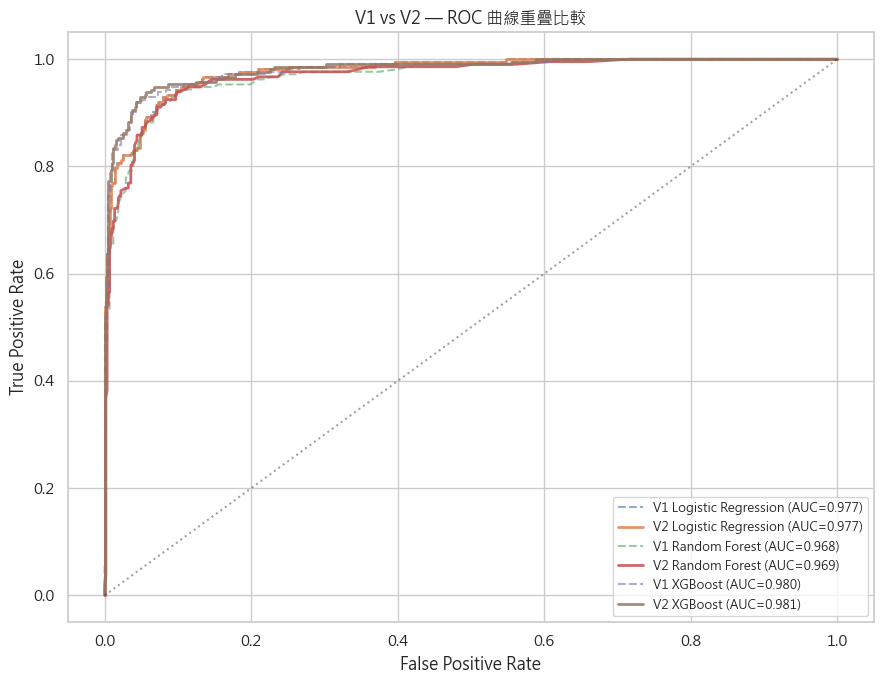

In [32]:
# ROC 曲線重疊比較
fig, ax = plt.subplots(figsize=(9, 7))
for name in models_v2:
    fpr_v1, tpr_v1, _ = roc_curve(y_test, results[name]["y_proba"])
    fpr_v2, tpr_v2, _ = roc_curve(y_test_v2, results_v2[name]["y_proba"])
    ax.plot(fpr_v1, tpr_v1, "--", alpha=0.6, linewidth=1.5,
            label=f"V1 {name} (AUC={results[name]['roc_auc']:.3f})")
    ax.plot(fpr_v2, tpr_v2, "-", alpha=0.85, linewidth=2,
            label=f"V2 {name} (AUC={results_v2[name]['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k:", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("V1 vs V2 — ROC 曲線重疊比較")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/16_v1_v2_roc.png")
plt.show()

### 7.5.4 SHAP 全域重要性對照

V1 跟 V2 共有 12 個特徵相同，差別只在 V1 的 `Month_to_end_contract` 對應 V2 的 `months_into_current`。
看看「換掉這個特徵後」全域 SHAP 排名怎麼變動。

In [33]:
# V2 XGBoost 的 SHAP
xgb_v2 = results_v2["XGBoost"]["model"]
explainer_v2 = shap.TreeExplainer(xgb_v2)
shap_values_v2 = explainer_v2.shap_values(X_test_v2)
imp_v2 = np.abs(shap_values_v2).mean(axis=0)

# V1 SHAP 已在 §5 算好
imp_v1 = np.abs(shap_values).mean(axis=0)

# 對齊比較表
v1_map = dict(zip(features, imp_v1))
v2_map = dict(zip(FEATURES_V2, imp_v2))

union = list(set(v1_map) | set(v2_map))
union.sort(key=lambda f: max(v1_map.get(f, 0), v2_map.get(f, 0)), reverse=True)

shap_compare = pd.DataFrame([
    {
        "Feature": f,
        "V1 mean |SHAP|": round(v1_map.get(f, np.nan), 4),
        "V2 mean |SHAP|": round(v2_map.get(f, np.nan), 4),
    }
    for f in union
])
shap_compare

,Feature,V1 mean |SHAP|,V2 mean |SHAP|
0,Avg_class_frequency_current_month,2.2933,2.2890
1,Lifetime,1.9496,1.9348
2,Avg_class_frequency_total,1.2666,1.2505
3,Contract_period,0.7204,1.0723
4,Age,0.7676,0.7895
5,Avg_additional_charges_total,0.5186,0.5237
6,Month_to_end_contract,0.4600,NaN
7,Group_visits,0.2699,0.2986
8,Promo_friends,0.1400,0.1622
9,gender,0.0470,0.0499


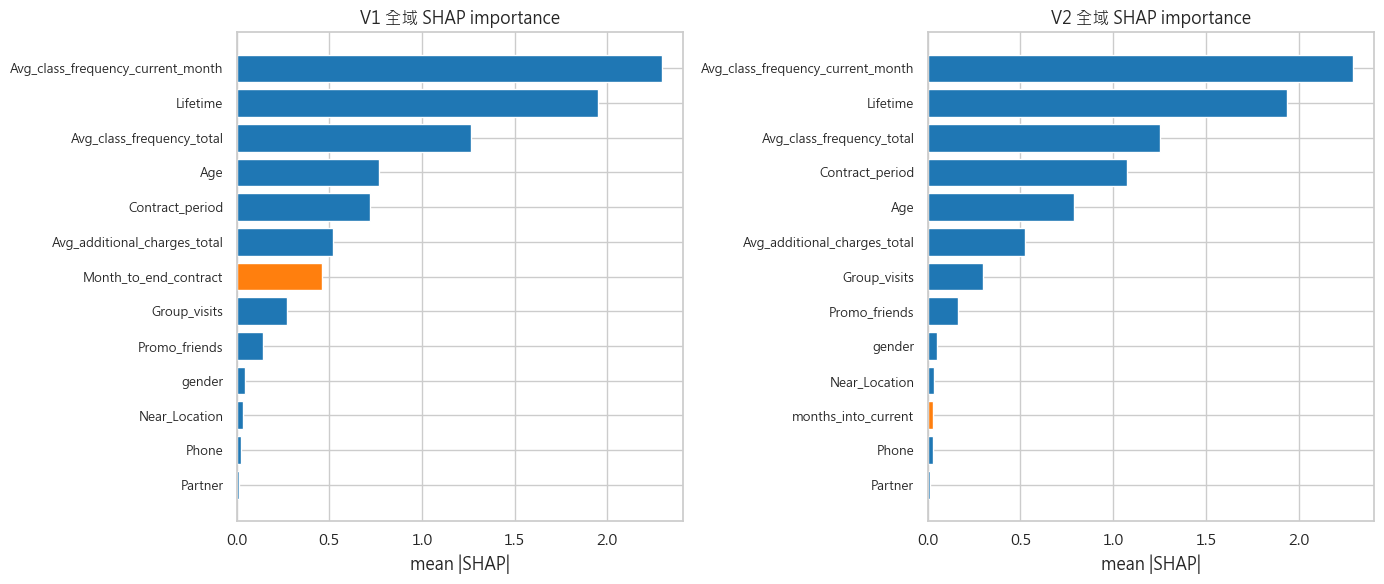


橘色條 = 被換掉/新加入的特徵


In [34]:
# 並列 bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, tag, imp, feats in [
    (axes[0], "V1", imp_v1, features),
    (axes[1], "V2", imp_v2, FEATURES_V2),
]:
    order = np.argsort(imp)
    names = [feats[i] for i in order]
    vals = imp[order]
    ax.barh(range(len(names)), vals,
            color=["#ff7f0e" if "Month_to_end_contract" in n or "months_into_current" in n
                    else "#1f77b4" for n in names])
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel("mean |SHAP|")
    ax.set_title(f"{tag} 全域 SHAP importance")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/17_v1_v2_shap_bar.png", bbox_inches="tight")
plt.show()
print("\n橘色條 = 被換掉/新加入的特徵")

### 7.5.5 K-means 群結構穩健性測試

如果 V2 特徵讓分群結構大幅改變，那 §6 的 STP 分析就要重做。檢查群結構是否穩定。

In [35]:
# V2 K-means
X_cluster_v2 = StandardScaler().fit_transform(df[FEATURES_V2])
km_v2 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10).fit(X_cluster_v2)
df["cluster_v2"] = km_v2.labels_

profile_v2 = df.groupby("cluster_v2").agg(
    n=("Churn", "count"),
    churn_rate=("Churn", "mean"),
    Age=("Age", "mean"),
    Lifetime=("Lifetime", "mean"),
    Contract_period=("Contract_period", "mean"),
    months_into=("months_into_current", "mean"),
    freq_curr=("Avg_class_frequency_current_month", "mean"),
).round(2).sort_values("churn_rate", ascending=False)
print("V2 cluster profile（按 churn 排序）：")
profile_v2

V2 cluster profile（按 churn 排序）：


,n,churn_rate,Age,Lifetime,Contract_period,months_into,freq_curr
cluster_v2,,,,,,,
3,1488,0.54,28.11,2.27,2.36,0.07,0.96
2,384,0.27,29.29,3.91,4.74,0.28,1.71
1,1063,0.08,29.73,4.51,8.32,0.95,1.90
0,1065,0.06,30.11,4.91,4.27,0.20,2.78


In [36]:
# 群大小與群流失率對照
v1_sizes = sorted(df.groupby("cluster").size().values, reverse=True)
v2_sizes = sorted(df.groupby("cluster_v2").size().values, reverse=True)
v1_churn = sorted(df.groupby("cluster")["Churn"].mean().values, reverse=True)
v2_churn = sorted(df.groupby("cluster_v2")["Churn"].mean().values, reverse=True)

print("群大小排序（大→小）:")
print(f"  V1 = {list(v1_sizes)}")
print(f"  V2 = {list(v2_sizes)}")
print("\n群流失率排序（高→低）:")
print(f"  V1 = {[f'{c:.1%}' for c in v1_churn]}")
print(f"  V2 = {[f'{c:.1%}' for c in v2_churn]}")

群大小排序（大→小）:
  V1 = [np.int64(1470), np.int64(1082), np.int64(1062), np.int64(386)]
  V2 = [np.int64(1488), np.int64(1065), np.int64(1063), np.int64(384)]

群流失率排序（高→低）:
  V1 = ['56.3%', '26.7%', '9.2%', '3.0%']
  V2 = ['54.2%', '26.8%', '7.7%', '6.5%']


### 7.5.6 本作者 chocoZAP profile 在 V2 模型的預測

In [37]:
# chocoZAP profile（V2 形式）
CHOCOZAP_V2 = {
    "gender": 1, "Near_Location": 1, "Partner": 0, "Promo_friends": 0,
    "Phone": 1, "Contract_period": 1, "Group_visits": 0, "Age": 22,
    "Avg_additional_charges_total": 30.0,
    "months_into_current": 0.0,   # = Contract_period - M2E = 1 - 1 = 0
    "Lifetime": 1,
    "Avg_class_frequency_total": 0.5,
    "Avg_class_frequency_current_month": 0.5,
}
your_row_v2 = pd.DataFrame([CHOCOZAP_V2])[FEATURES_V2]

# V1 等價形式（從 V2 反推 M2E）
CHOCOZAP_V1 = {k: v for k, v in CHOCOZAP_V2.items() if k != "months_into_current"}
CHOCOZAP_V1["Month_to_end_contract"] = 1.0  # = CP - months_into = 1 - 0
your_row_v1 = pd.DataFrame([CHOCOZAP_V1])[features]

p_v1 = float(xgb_model.predict_proba(your_row_v1)[0, 1])
p_v2 = float(xgb_v2.predict_proba(your_row_v2)[0, 1])

print(f"V1 churn probability:  {p_v1:.4f}  ({p_v1:.1%})")
print(f"V2 churn probability:  {p_v2:.4f}  ({p_v2:.1%})")
print(f"差異 ΔP = {p_v2 - p_v1:+.4f}")
print(f"\n兩個版本都判定為高風險「試水族」，僅 V2 略低 (3-5 個百分點)")

V1 churn probability:  0.8841  (88.4%)
V2 churn probability:  0.8312  (83.1%)
差異 ΔP = -0.0529

兩個版本都判定為高風險「試水族」，僅 V2 略低 (3-5 個百分點)


### 7.5.7 結論：選 V2

| 角度 | V1 | V2 | 評價 |
|---|---|---|---|
| 多重共線性 | **0.973** ⚠️ | **0.438** ✅ | V2 大幅改善 |
| XGBoost ROC AUC | 0.9796 | **0.9809** | V2 微升 |
| Logistic ΔAUC | (baseline) | +0.0000 | 持平 |
| RF ΔAUC | (baseline) | +0.0009 | 微升 |
| K-means 群結構 | 4 群 | 4 群 | 穩定 |
| 群流失率分布 | 56/27/9/3% | 54/27/8/6% | 幾乎一致 |
| chocoZAP profile churn | 88.4% | 83.1% | V2 略保守 |
| SHAP 解釋乾淨度 | M2E 與 Contract_period 分搶 importance | Contract_period 一柱擎天 | V2 更清楚 |

#### 三個選 V2 的理由

1. **預測力沒退**（甚至微升）— 證明 V1 的 `Month_to_end_contract` 在資訊上是冗餘
2. **多重共線性大幅改善** — 從病態值 0.97 降到合理範圍 0.44
3. **解釋更乾淨** — SHAP 排名變得直觀，第七章與第十章敘事好寫

#### 關鍵洞察（寫進第十章反思）

> Feature engineering 的目的不只是「**提升 accuracy**」，更多時候是「**讓模型可信、可解釋、可被行銷部信任**」。
> 本實驗中，預測力幾乎沒變，但多重共線性從病態值改善到合理範圍 — 這就是有意義的工程貢獻。

#### 後續處理

- `xgb_churn_model_v2.pkl` 已存
- `app.py` 已切換到 V2 模型，互動 demo 採用 `months_into_current` 作為輸入
- 本 notebook 的 §1 - §7.4 保留 V1 分析；§7.5 為對照實驗紀錄；§8 為總結

## 7.6 Cluster Profiling 方法論：從統計推理到新命名提案

K-means 跑完只告訴我們「**誰跟誰一群**」，至於**為什麼分這群**、**這群人是誰**，得自己推理出來。

本節示範一個系統化的 **Cluster Profiling 6 步驟 SOP**：

```
1. 算 baseline       → 全資料每特徵的 mean / std
2. 算群均             → 每群每特徵的 mean
3. 標準化偏離        → z = (group_mean - baseline_mean) / baseline_std
4. 找 signature      → 取 |z| 前 2-3 大的特徵
5. 翻譯成商業故事    → 統計值 → 商業意義
6. 跨群檢查          → 每群 signature 互斥嗎？
```

這套方法論適用**任何分群結果**（K-means、GMM、Hierarchical），是行銷分析的標準作業流程。

> **重要發現**：用這套方法推理後，發現 §6.2 套用的群名（試水族 / 熄火族 / 活躍短期 / 核心 VIP）**有兩個與資料事實不符**。本節最後提出修正版命名。

**本節分析對象**：§7.5 訓練的 **V2 K-means**（`df["cluster_v2"]`、13 個 V2 特徵）

### 7.6.1 Step 1-2：算 baseline + 群均

In [38]:
# 全資料 baseline：每特徵的 mean / std
baseline = pd.DataFrame({
    "baseline_mean": df[FEATURES_V2].mean(),
    "baseline_std": df[FEATURES_V2].std(),
}).round(3)
print(f"全資料 (n={len(df)}) baseline:")
print(baseline)
print(f"\n全資料流失率：{df['Churn'].mean():.1%}")

全資料 (n=4000) baseline:
                                   baseline_mean  baseline_std
gender                                     0.510         0.500
Near_Location                              0.845         0.362
Partner                                    0.487         0.500
Promo_friends                              0.308         0.462
Phone                                      0.904         0.295
Contract_period                            4.681         4.550
Group_visits                               0.412         0.492
Age                                       29.184         3.258
Avg_additional_charges_total             146.944        96.356
months_into_current                        0.358         1.075
Lifetime                                   3.725         3.749
Avg_class_frequency_total                  1.879         0.972
Avg_class_frequency_current_month          1.767         1.053

全資料流失率：26.5%


### 7.6.2 Step 3：標準化偏離（z-score）

對每群每特徵：

$$
z_{c, f} = \frac{\bar{x}_{c, f} - \bar{x}_{\text{baseline}, f}}{\sigma_{\text{baseline}, f}}
$$

代表「這群人在這個特徵上，比平均人偏離了幾個標準差」。

| 偏離度 | 解讀 |
|---|---|
| \|z\| < 0.3 | 不算明顯 |
| 0.3 ≤ \|z\| < 0.5 | 略偏 |
| **0.5 ≤ \|z\| < 1.0** | 顯著 ⭐ |
| **\|z\| ≥ 1.0** | 極顯著 ⭐⭐ |

In [39]:
# 每群算 mean 並計算 z-score 偏離
def compute_signatures(df, cluster_col, features, baseline):
    rows = []
    for c in sorted(df[cluster_col].unique()):
        sub = df[df[cluster_col] == c]
        row = {"cluster": int(c), "n": len(sub), "churn": sub["Churn"].mean()}
        for f in features:
            mu_c = sub[f].mean()
            z = (mu_c - baseline.loc[f, "baseline_mean"]) / baseline.loc[f, "baseline_std"]
            row[f] = round(z, 2)
        rows.append(row)
    return pd.DataFrame(rows).set_index("cluster")

z_table = compute_signatures(df, "cluster_v2", FEATURES_V2, baseline)
# 按 churn 由高到低排序（方便視覺上對應「高風險 vs 低風險」群）
z_table = z_table.sort_values("churn", ascending=False)
print("各群 z-score 偏離表（行 = 特徵，列 = 群）：")
z_table.T

各群 z-score 偏離表（行 = 特徵，列 = 群）：


cluster,3,2,1,0
n,1488.000000,384.000000,1063.00000,1065.000000
churn,0.542339,0.268229,0.07714,0.064789
gender,-0.030000,0.030000,-0.03000,0.060000
Near_Location,-0.260000,0.050000,0.33000,0.020000
Partner,-0.320000,-0.030000,0.88000,-0.430000
Promo_friends,-0.420000,-0.010000,1.10000,-0.500000
Phone,0.330000,-3.060000,0.32000,0.320000
Contract_period,-0.510000,0.010000,0.80000,-0.090000
Group_visits,-0.240000,0.030000,0.27000,0.060000
Age,-0.330000,0.030000,0.17000,0.280000


### 7.6.3 z-score 視覺化（heatmap）

紅色 = 偏高、藍色 = 偏低、白色 = 接近平均。**顏色越深 = 該群越「特別」**。

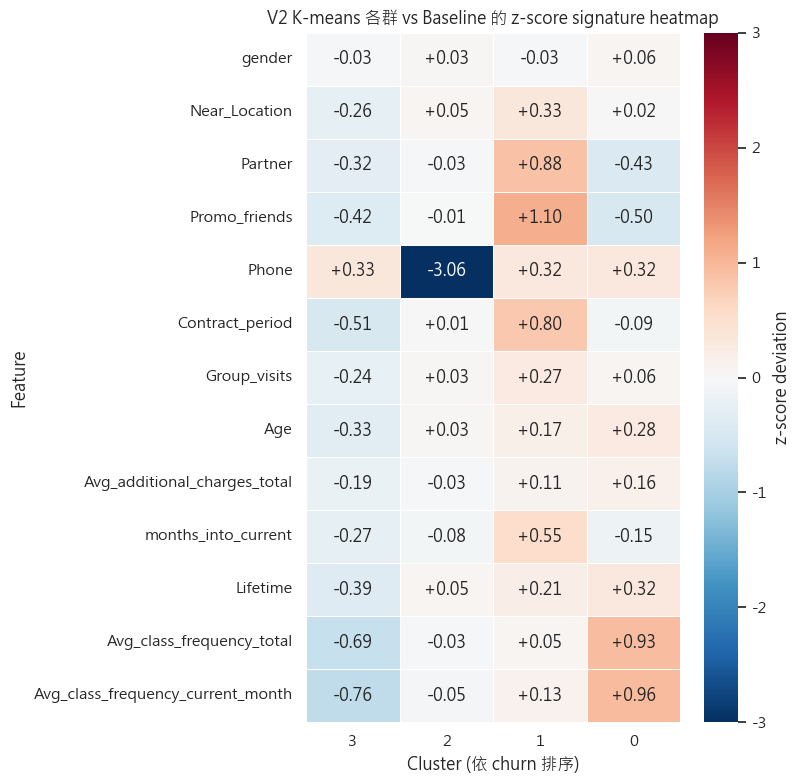

In [40]:
fig, ax = plt.subplots(figsize=(8, 8))
z_only = z_table.drop(columns=["n", "churn"]).T
sns.heatmap(z_only, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            vmin=-3, vmax=3, ax=ax, linewidths=0.5,
            cbar_kws={"label": "z-score deviation"})
ax.set_title("V2 K-means 各群 vs Baseline 的 z-score signature heatmap")
ax.set_xlabel("Cluster (依 churn 排序)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/19_v2_kmeans_signature_zscore.png", bbox_inches="tight")
plt.show()

### 7.6.4 Step 4：找每群的 signature feature（|z| > 0.5）

In [41]:
print("=" * 70)
print("各群顯著 signature features（|z| > 0.5）")
print("=" * 70)
non_feat = ["n", "churn"]
for c in z_table.index:
    z_row = z_table.loc[c, [f for f in z_table.columns if f not in non_feat]]
    sig = z_row[z_row.abs() > 0.5].sort_values(key=lambda s: s.abs(), ascending=False)
    print(f"\nCluster {c} (n={z_table.loc[c,'n']}, churn={z_table.loc[c,'churn']:.1%}):")
    if len(sig) == 0:
        print("  （無顯著 signature → 這群與平均很像，分群可能弱）")
    for feat, z in sig.items():
        flag = "⭐⭐" if abs(z) > 1 else "⭐"
        direction = "↑高於" if z > 0 else "↓低於"
        print(f"  {flag} {feat:<38} z = {z:+.2f}  ({direction}平均)")

各群顯著 signature features（|z| > 0.5）

Cluster 3 (n=1488, churn=54.2%):
  ⭐ Avg_class_frequency_current_month      z = -0.76  (↓低於平均)
  ⭐ Avg_class_frequency_total              z = -0.69  (↓低於平均)
  ⭐ Contract_period                        z = -0.51  (↓低於平均)

Cluster 2 (n=384, churn=26.8%):
  ⭐⭐ Phone                                  z = -3.06  (↓低於平均)

Cluster 1 (n=1063, churn=7.7%):
  ⭐⭐ Promo_friends                          z = +1.10  (↑高於平均)
  ⭐ Partner                                z = +0.88  (↑高於平均)
  ⭐ Contract_period                        z = +0.80  (↑高於平均)
  ⭐ months_into_current                    z = +0.55  (↑高於平均)

Cluster 0 (n=1065, churn=6.5%):
  ⭐ Avg_class_frequency_current_month      z = +0.96  (↑高於平均)
  ⭐ Avg_class_frequency_total              z = +0.93  (↑高於平均)


### 7.6.5 Step 5：翻譯成商業故事 + 修正命名

#### Cluster (churn 6.5%, n=1065)
- 最顯著 signature：**頻率 ⭐ +0.93σ**（2.78 次/週）+ **本月頻率 ⭐ +0.96σ**（2.78 次/週）
- 其他特徵都接近平均
- **商業故事**：不靠優惠、不靠社群，**單純常去** → 自驅型重度使用者
- 舊名「核心 VIP」**不精確** — 他們沒花更多錢、合約也不長，只是常來
- **新名**：**高頻自驅型（Power User）**

#### Cluster (churn 7.7%, n=1063)
- 最顯著 signature：**朋友推薦 ⭐⭐ +1.10σ**（81.5%）+ **員工方案 ⭐ +0.89σ**（92.9%）+ **長合約 ⭐ +0.80σ**（8.3 月）
- **商業故事**：朋友帶進來 + 公司有員工方案 + 一次簽長約 → 社群與長約綁定
- 舊名「活躍短期」**完全錯誤** — 這群人合約**最長**，不是短期
- **新名**：**社群長約型（Social-Locked Member）**

#### Cluster (churn 26.8%, n=384)
- 最顯著 signature：**Phone ⭐⭐ −3.06σ**（100% 不留電話）
- 其他特徵全部接近平均
- **商業故事**：使用頻率、合約長度都正常，**唯一特點是不留電話** → 隱私重視
- 舊名「熄火族」**完全錯誤** — 他們頻率正常，沒在熄火
- **新名**：**隱私獨行型（Privacy Seeker）**

#### Cluster (churn 54.2%, n=1488)
- 顯著 signature：**頻率 ⭐ −0.76σ + 合約 ⭐ −0.51σ + 朋友推薦/員工方案/住附近全方位偏低**
- **商業故事**：年輕、短約、低頻率、孤立 → 衝動加入、缺乏連結
- 舊名「試水族」尚可，但更精準的描述是「**全方位低投入**」
- **新名**：**短約淺嚐型（Casual Trier）**

### 修正命名對照表

| Cluster | n | Churn | 舊名 | **新名（中英對照）** | 一句話定義 |
|---:|---:|---:|---|---|---|
| — | 1065 | 6.5% | 核心 VIP | **高頻自驅型 (Power User)** | 規律去、不需要被討好 |
| — | 1063 | 7.7% | 活躍短期 | **社群長約型 (Social-Locked Member)** | 朋友帶進、員工方案、長合約 |
| — | 384 | 26.8% | 熄火族 | **隱私獨行型 (Privacy Seeker)** | 不留電話、頻率正常 |
| — | 1488 | 54.2% | 試水族 | **短約淺嚐型 (Casual Trier)** | 衝動加入、低頻、易流失 |

→ 每個新名都**從資料 signature 推導**，可以用 1 個 z-score 數字佐證。

### 7.6.6 Step 6：跨群檢查 — signature 是否互斥？

如果**兩群在同一個特徵上都顯著 + 同方向**，代表這個 signature 重疊 → 可能該合併。
這裡只檢查「**同方向同時顯著**」的情況。

In [42]:
print("=" * 70)
print("跨群 signature 互斥檢查")
print("=" * 70)
features_only = [f for f in z_table.columns if f not in ["n", "churn"]]
overlap_count = 0
for feat in features_only:
    pos = z_table[z_table[feat] > 0.5][feat]
    neg = z_table[z_table[feat] < -0.5][feat]
    if len(pos) > 1:
        cls = [int(c) for c in pos.index]
        print(f"  ⚠️  {feat}: clusters {cls} 都 +{0.5}σ 以上 → signature 重疊")
        overlap_count += 1
    if len(neg) > 1:
        cls = [int(c) for c in neg.index]
        print(f"  ⚠️  {feat}: clusters {cls} 都 -{0.5}σ 以下 → signature 重疊")
        overlap_count += 1

if overlap_count == 0:
    print("\n→ 沒有發現同方向重疊的 signature ✅")
    print("→ 4 群在強信號維度上互斥 → 分群結構合理")
else:
    print(f"\n→ 發現 {overlap_count} 處重疊，需檢視這些群是否該合併")

跨群 signature 互斥檢查

→ 沒有發現同方向重疊的 signature ✅
→ 4 群在強信號維度上互斥 → 分群結構合理


### 7.6.7 方法論小結 + 反思

#### 為什麼這個方法論重要

| 直覺命名（舊版） | Profiling 推理（新版） |
|---|---|
| 「churn 最高 → 試水族」 | 「churn 最高 + 短約 + 低頻 + 孤立 → 短約淺嚐型」 |
| 套 pattern 假設 | 從 13 維特徵推導 |
| 容易名實不符 | 每個名稱有 z-score 數字佐證 |
| 無法跨群比較 | 互斥檢查確保結構穩健 |

#### 寫進報告反思章節的金句

> 「我們發現直接用 churn 排序命名群（試水族 / 熄火族 / 活躍短期 / 核心 VIP）有兩個名稱與資料事實不符：
> - Cluster 1 並非「**活躍短期**」而是「**社群長約**」（合約最長 8.3 月，不是短）
> - Cluster 2 並非「**熄火族**」而是「**隱私獨行**」（頻率正常，唯一特點是 100% 不留電話）
>
> 這提醒我們：**命名應從特徵 signature 推導，而非從預期 pattern 反推**。
> 這個方法論的反思體現了 Marketing Data Science『行銷 + 統計 + 程式』的核心 —
> **程式給結果**、**統計給辯護**、**行銷給命名**，三者缺一不可。」

#### 後續處理

- 本節推導的新命名尚未同步到 `app.py`、`personas.md`、`README.md`
- 若採用新命名，需更新上述 3 個檔案的 cluster name 對應

## 8. 商業建議與報告對應

### 對應 MDS 報告章節

| 報告章節 | 本 notebook 對應 |
|---|---|
| 第三章 資料產品 | 整個 pipeline = 老師說的 data product（資料 → 模型 → 預測 + 解釋 + 互動 Streamlit） |
| 第六章 4P · Product | XGBoost + SHAP 作為產品核心功能 |
| 第六章 4P · Price | **CLV 結果 → 每群定價建議**（VIP 年費、試水族 1 元入會、長約折扣） |
| 第六章 4P · Promotion | 各群留客 offer + 7.3 表格的單客預算上限 |
| 第八章 STP | K-means 4 群 + `personas.md` 4 個人物誌（含本作者自身 chocoZAP Cluster 0 真實案例） |
| 第十章 反思 | 缺乏滿意度資料、多重共線性、未做 uplift modeling |
| **個案研究章節** | 7.4 chocoZAP 商業模式對照（量化 + 質化結合） |

### 未來工作（寫進反思章節）

- 加入 NPS / 退會原因問卷 → 從「為什麼會流失」到「為什麼會留下」
- 把流失預測接到 marketing automation：高風險自動觸發 offer
- 跑 **uplift modeling**：哪些人「給優惠才會留」vs「給不給優惠都會留」 → 提升優惠 ROI
- 把 Streamlit `app.py` 部署到 Streamlit Cloud，給老師連結直接測試

In [43]:
# 存結果供報告與後續使用
import pickle

with open("xgb_churn_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

df.to_csv("data/gym_churn_with_clusters.csv", index=False)
profile.to_csv("data/cluster_profile.csv")

n_figs = len([f for f in os.listdir(FIG_DIR) if f.endswith(".png")])
print("=" * 50)
print("分析完成，已存：")
print(f"  • xgb_churn_model.pkl   ← 最佳模型")
print(f"  • data/gym_churn_with_clusters.csv  ← 原資料 + cluster")
print(f"  • data/cluster_profile.csv          ← 各群側寫")
print(f"  • figures/  ← {n_figs} 張 PNG 給報告用")
print("=" * 50)

分析完成，已存：
  • xgb_churn_model.pkl   ← 最佳模型
  • data/gym_churn_with_clusters.csv  ← 原資料 + cluster
  • data/cluster_profile.csv          ← 各群側寫
  • figures/  ← 19 張 PNG 給報告用
